In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

import warnings
warnings.filterwarnings('ignore')

In [2]:
con = sqlite3.connect('travel.sqlite')
cursor = con.cursor()


In [3]:
cursor.execute("""select name from sqlite_master where type ='table';""")
print('List of tables present in the database') 
table_list = [table[0] for table in cursor.fetchall()]

table_list

List of tables present in the database


['aircrafts_data',
 'airports_data',
 'boarding_passes',
 'bookings',
 'flights',
 'seats',
 'ticket_flights',
 'tickets']

### EDA of Data

In [3]:
aircrafts_data = pd.read_sql_query("select * from aircrafts_data", con)
aircrafts_data

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600
5,319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-...",6700
6,733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
7,CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208...",1200
8,CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье ...",2700


In [5]:
airports_data = pd.read_sql_query("select * from airports_data", con)
airports_data

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin
...,...,...,...,...,...
99,MMK,"{""en"": ""Murmansk Airport"", ""ru"": ""Мурманск""}","{""en"": ""Murmansk"", ""ru"": ""Мурманск""}","(32.7508010864257812,68.7817001342773438)",Europe/Moscow
100,ABA,"{""en"": ""Abakan Airport"", ""ru"": ""Абакан""}","{""en"": ""Abakan"", ""ru"": ""Абакан""}","(91.3850021362304688,53.7400016784667969)",Asia/Krasnoyarsk
101,BAX,"{""en"": ""Barnaul Airport"", ""ru"": ""Барнаул""}","{""en"": ""Barnaul"", ""ru"": ""Барнаул""}","(83.5384979248046875,53.363800048828125)",Asia/Krasnoyarsk
102,AAQ,"{""en"": ""Anapa Vityazevo Airport"", ""ru"": ""Витяз...","{""en"": ""Anapa"", ""ru"": ""Анапа""}","(37.3473014831539984,45.002101898192997)",Europe/Moscow


In [4]:
boarding_passes = pd.read_sql_query("select * from boarding_passes", con)
boarding_passes

,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A
...,...,...,...,...
579681,0005434302871,19945,85,20F
579682,0005432892791,19945,86,21C
579683,0005434302869,19945,87,20E
579684,0005432802476,19945,88,21F


In [7]:
bookings = pd.read_sql_query("select * from bookings", con)
bookings

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [5]:
flights = pd.read_sql_query("select * from flights", con)
flights

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N
...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03
33117,33118,PG0063,2017-07-28 19:25:00+03,2017-07-28 20:10:00+03,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03,2017-07-28 20:15:00+03
33118,33119,PG0063,2017-09-08 19:25:00+03,2017-09-08 20:10:00+03,SKX,SVO,Scheduled,CR2,\N,\N
33119,33120,PG0063,2017-08-01 19:25:00+03,2017-08-01 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03,2017-08-01 20:12:00+03


In [6]:
seats = pd.read_sql_query("select * from seats", con)
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [7]:
ticket_flights = pd.read_sql_query("select * from ticket_flights", con)
ticket_flights

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100
...,...,...,...,...
1045721,0005435097522,32094,Economy,5200
1045722,0005435097521,32094,Economy,5200
1045723,0005435104384,32094,Economy,5200
1045724,0005435104352,32094,Economy,5200


In [11]:
tickets = pd.read_sql_query("select * from tickets", con)
tickets

,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589
...,...,...,...
366728,0005435999869,D730BA,0474 690760
366729,0005435999870,D730BA,6535 751108
366730,0005435999871,A1AD46,1596 156448
366731,0005435999872,7B6A53,9374 822707


In [16]:
for i in table_list:
    print('\ntable:', i)
    column_info = con.execute("PRAGMA table_info({})".format(i))
    for column in column_info.fetchall():
        print(column[1:3])
    


table: aircrafts_data
('aircraft_code', 'character(3)')
('model', 'jsonb')
('range', 'INTEGER')

table: airports_data
('airport_code', 'character(3)')
('airport_name', 'jsonb')
('city', 'jsonb')
('coordinates', 'point')
('timezone', 'TEXT')

table: boarding_passes
('ticket_no', 'character(13)')
('flight_id', 'INTEGER')
('boarding_no', 'INTEGER')
('seat_no', 'character varying(4)')

table: bookings
('book_ref', 'character(6)')
('book_date', 'timestamp with time zone')
('total_amount', 'numeric(10,2)')

table: flights
('flight_id', 'INTEGER')
('flight_no', 'character(6)')
('scheduled_departure', 'timestamp with time zone')
('scheduled_arrival', 'timestamp with time zone')
('departure_airport', 'character(3)')
('arrival_airport', 'character(3)')
('status', 'character varying(20)')
('aircraft_code', 'character(3)')
('actual_departure', 'timestamp with time zone')
('actual_arrival', 'timestamp with time zone')

table: seats
('aircraft_code', 'character(3)')
('seat_no', 'character varying(4

In [17]:
for i in table_list:
    print('\ntable:', i)
    df_table = pd.read_sql_query(f"select * from {i}", con)
    print(df_table.isnull().sum())


table: aircrafts_data
aircraft_code    0
model            0
range            0
dtype: int64

table: airports_data
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64

table: boarding_passes
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64

table: bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64

table: flights
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64

table: seats
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64

table: ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64

table: tickets
ticket_no       0
book_ref        0
passenger_id    0
dtype: int64


## Basic Analysis

#### How many plans have more than 100 seats?

In [19]:
pd.read_sql_query("""select aircraft_code, count(*) as num_seats from seats
group by aircraft_code
having count(*) > 100""", con)

,aircraft_code,num_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402


#### How the number of tickets booked and total amount earned changed with the time?

In [15]:
tickets = pd.read_sql_query("""select * from tickets inner join bookings
on tickets.book_ref = bookings.book_ref""", con)

tickets['book_date'] = pd.to_datetime(tickets['book_date'])
tickets.dtypes

ticket_no                          object
book_ref                           object
passenger_id                       object
book_ref                           object
book_date       datetime64[ns, UTC+03:00]
total_amount                        int64
dtype: object

In [16]:
tickets['date'] = tickets['book_date'].dt.date

In [13]:
bookings

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [17]:
tickets

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount,date
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
1,0005432000988,06B046,8499 420203,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
2,0005432000989,E170C3,1011 752484,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
3,0005432000990,E170C3,4849 400049,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
4,0005432000991,F313DD,6615 976589,F313DD,2017-07-03 04:37:00+03:00,30900,2017-07-03
...,...,...,...,...,...,...,...
366728,0005435999869,D730BA,0474 690760,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366729,0005435999870,D730BA,6535 751108,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366730,0005435999871,A1AD46,1596 156448,A1AD46,2017-08-13 03:49:00+03:00,45900,2017-08-13
366731,0005435999872,7B6A53,9374 822707,7B6A53,2017-08-15 15:54:00+03:00,219400,2017-08-15


In [24]:
x = tickets.groupby('date')[['date']].count()

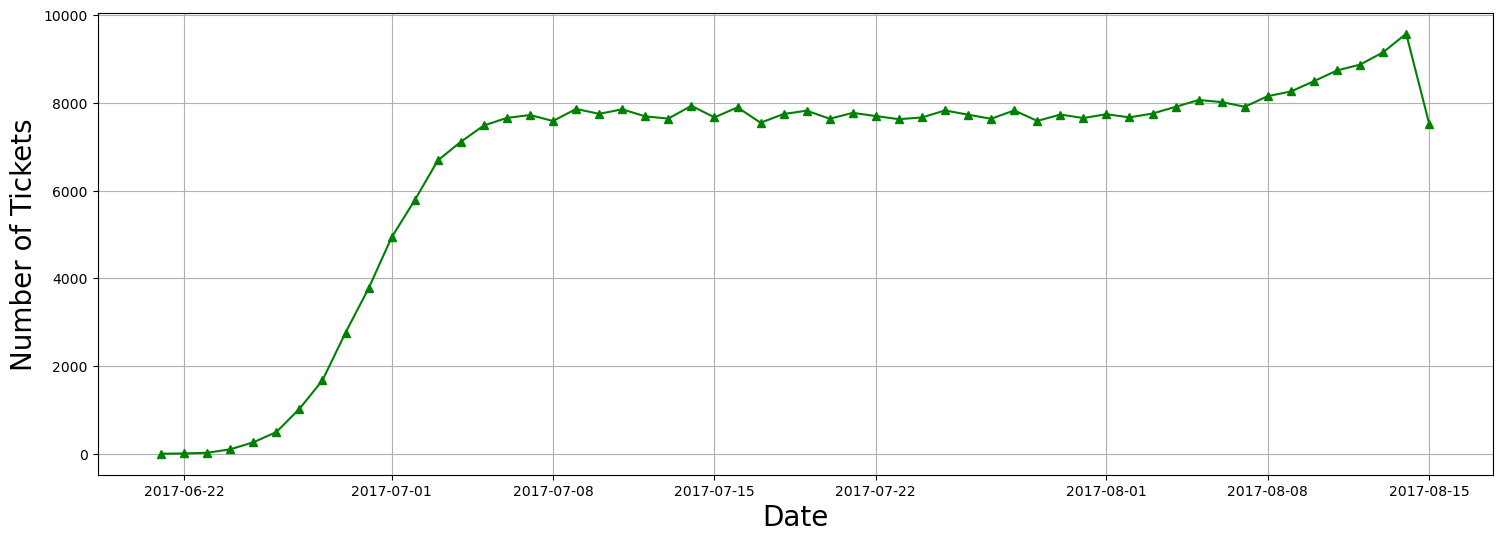

In [25]:
plt.figure(figsize = (18,6))
plt.plot(x.index, x['date'], marker = '^', color = 'green')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Number of Tickets', fontsize = 20)
plt.grid('b')
plt.show()

In [14]:
bookings = pd.read_sql_query("select * from bookings", con) 
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['date'] = bookings['book_date'].dt.date
x = bookings.groupby('date')[['total_amount']].sum()


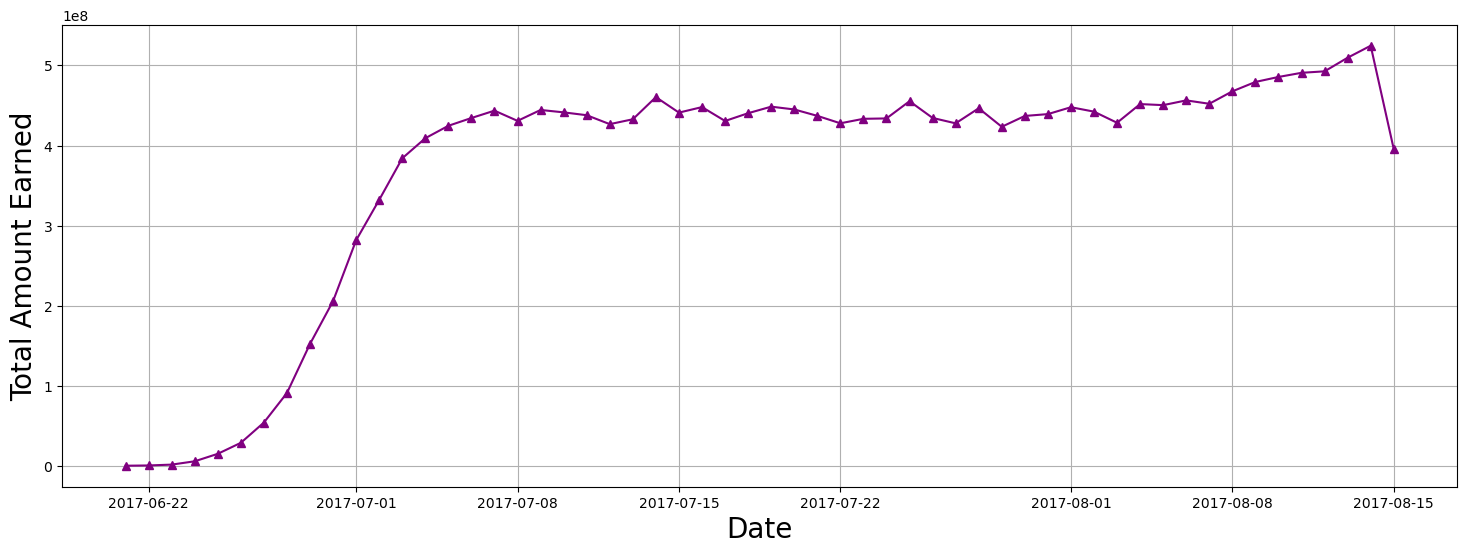

In [16]:
plt.figure(figsize = (18,6))
plt.plot(x.index, x['total_amount'], marker = '^', color = 'purple')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Total Amount Earned', fontsize = 20)
plt.grid('b')
plt.show()

 #### Calculate the average charge for each aircraft with different fare conditions

In [12]:
df = pd.read_sql_query("""
SELECT 
    fare_conditions, 
    aircraft_code, 
    AVG(amount) AS avg_amount,
    COUNT(ticket_no) AS passenger_count
FROM ticket_flights
JOIN flights 
    ON ticket_flights.flight_id = flights.flight_id
GROUP BY aircraft_code, fare_conditions
""", con)

In [13]:
df

,fare_conditions,aircraft_code,avg_amount,passenger_count
0,Business,319,113550.557703,9055
1,Economy,319,38311.402347,43798
2,Business,321,34435.662664,17573
3,Economy,321,11534.974764,89556
4,Business,733,41865.626175,7977
5,Economy,733,13985.152000,78125
6,Business,763,82839.842866,16801
7,Economy,763,27594.721829,107973
8,Business,773,57779.909435,10821
9,Comfort,773,32740.552889,17291


In [52]:
aircraft_table = df.rename(columns={
    'avg(amount)': 'avg_amount'
})

# optional: reorder columns like your pandas version
aircraft_table = aircraft_table[
    ['aircraft_code', 'fare_conditions', 'avg_amount', 'passenger_count']
]

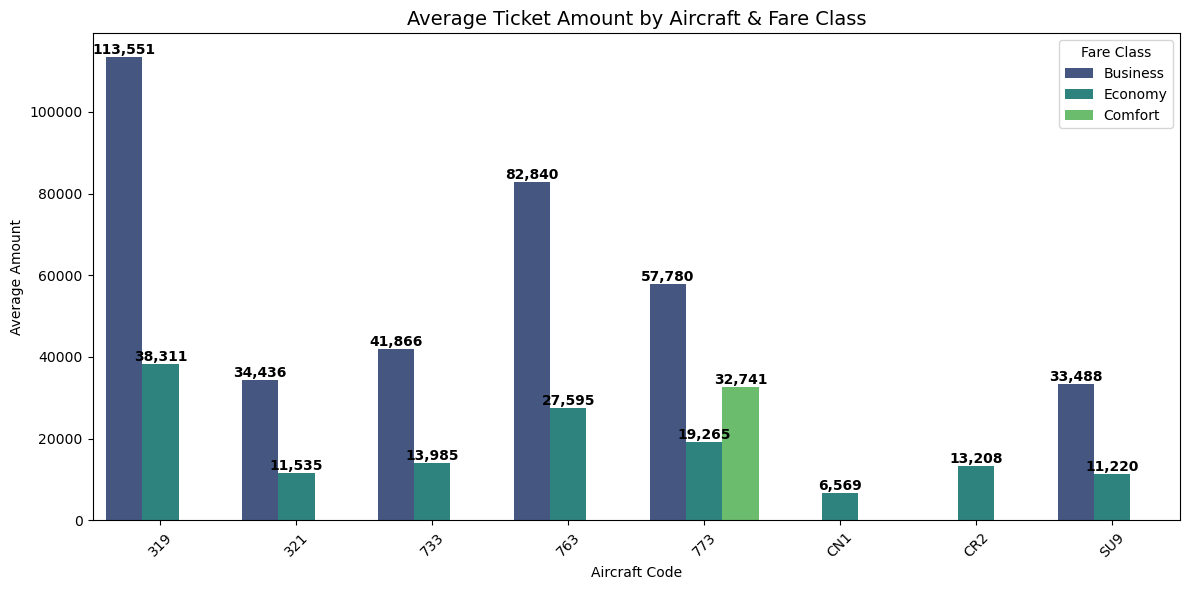

In [51]:
plt.figure(figsize = (12,6))

ax = sns.barplot(
    data=df,
    x='aircraft_code',
    y='avg_amount',             
    hue='fare_conditions',
    palette='viridis',
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average Ticket Amount by Aircraft & Fare Class", fontsize=14)
plt.xlabel("Aircraft Code")
plt.ylabel("Average Amount")

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:,.0f}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight = 'bold'
        )

plt.legend(title="Fare Class")
plt.tight_layout()
plt.show()

## Analyzing occupency rate
#### For each aircraft, calculte the total revenue per year and the average revenue per ticket

In [5]:
pd.read_sql_query("""select aircraft_code, ticket_count, total_revenue, total_revenue / ticket_count as avg_rev_per_ticket from
(select aircraft_code, count(*) as ticket_count, sum(amount) as total_revenue from ticket_flights
                    join flights on ticket_flights.flight_id = flights.flight_id group by aircraft_code)""", con)

,aircraft_code,ticket_count,total_revenue,avg_rev_per_ticket
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


#### Calculate the average occupancy per aircraft

In [45]:
occupancy_rate = pd.read_sql_query("""select 
                        a.aircraft_code, 
                        avg(a.seats_count) as avg_booked_seats,
                        b.num_seats, 
                        avg(a.seats_count) / b.num_seats as occupancy_rate 
                     from(
                        select 
                           aircraft_code, 
                           flights.flight_id, 
                           count(*) as seats_count
                     from boarding_passes
                     inner join flights 
                     on boarding_passes.flight_id = flights.flight_id
                     group by aircraft_code, flights.flight_id) as a
                     inner join(
                              select 
                                 aircraft_code,
                                 count(*) as num_seats 
                              from seats 
                              group by aircraft_code) as b
                              on a.aircraft_code = b.aircraft_code group by a.aircraft_code""", con) 

In [46]:
occupancy_rate

,aircraft_code,avg_booked_seats,num_seats,occupancy_rate
0,319,53.583181,116,0.461924
1,321,88.809231,170,0.522407
2,733,80.255462,130,0.617350
3,763,113.937294,222,0.513231
4,773,264.925806,402,0.659019
5,CN1,6.004431,12,0.500369
6,CR2,21.482847,50,0.429657
7,SU9,56.812113,97,0.585692


#### Calculate by how much the total turnover could increase by giving all aircraft a 10% higher occupancy rate 

In [47]:
occupancy_rate['Inc occupancy rate'] = occupancy_rate['occupancy_rate'] + occupancy_rate['occupancy_rate'] * 0.1

In [48]:
occupancy_rate

,aircraft_code,avg_booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.583181,116,0.461924,0.508116
1,321,88.809231,170,0.522407,0.574648
2,733,80.255462,130,0.617350,0.679085
3,763,113.937294,222,0.513231,0.564554
4,773,264.925806,402,0.659019,0.724921
5,CN1,6.004431,12,0.500369,0.550406
6,CR2,21.482847,50,0.429657,0.472623
7,SU9,56.812113,97,0.585692,0.644261


In [50]:
total_revenue = pd.read_sql_query("""select aircraft_code, sum(amount) as total_revenue from ticket_flights
join flights on ticket_flights.flight_id = flights.flight_id group by aircraft_code""", con) 

In [51]:
pd.set_option("display.float_format", str)

In [52]:
occupancy_rate['Inc Total Annual Turnover'] = (total_revenue['total_revenue'] / occupancy_rate['occupancy_rate'])*occupancy_rate['occupancy_rate']
occupancy_rate

,aircraft_code,avg_booked_seats,num_seats,occupancy_rate,Inc occupancy rate,Inc Total Annual Turnover
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726,2706163100.0
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905,1638164100.0
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565,1426552100.0000002
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146,4371277100.0
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492,3431205500.0
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727,96373800.0
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382,1982760500.0
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144,5114484700.0


## Making final summary table for visualization

In [29]:
# Passenger count per flight
passengers = boarding_passes.groupby('flight_id')['ticket_no'].count().reset_index()
passengers.rename(columns={'ticket_no':'passenger_count'}, inplace=True)

# Seat capacity
capacity = seats.groupby('aircraft_code')['seat_no'].count().reset_index()
capacity.rename(columns={'seat_no':'total_seats'}, inplace=True)

# Merge
occ = flights[['flight_id','aircraft_code']].merge(passengers, on='flight_id', how='left')
occ = occ.merge(capacity, on='aircraft_code', how='left')

# Occupancy
occ['occupancy_rate'] = occ['passenger_count'] / occ['total_seats']

# Aircraft level
occupancy_table = occ.groupby('aircraft_code')['occupancy_rate'].mean().reset_index()

In [30]:
total_revenue = ticket_flights['amount'].sum()
total_passengers = ticket_flights['ticket_no'].count()

kpi_table = pd.DataFrame({
    'Total Revenue': [total_revenue],
    'Total Passengers': [total_passengers]
})

In [15]:
df['book_date'] = pd.to_datetime(df['book_date'])

df['year'] = df['book_date'].dt.year
df['month'] = df['book_date'].dt.month

In [16]:
passengers = boarding_passes.groupby('flight_id')['ticket_no'].count().reset_index()
passengers.rename(columns={'ticket_no':'passenger_count'}, inplace=True)

df = df.merge(passengers, on='flight_id', how='left')

In [18]:
final_table1 = df[[
    'flight_id', 
    'book_date',
    'year',
    'month',
    'aircraft_code',
    'fare_conditions',
    'departure_city',
    'arrival_city',
    'amount'
]]

NameError: name 'df' is not defined

In [20]:
capacity = seats.groupby('aircraft_code')['seat_no'].count().reset_index()
capacity.rename(columns={'seat_no':'total_seats'}, inplace=True)


In [24]:
final_table = final_table.merge(
    capacity,
    on='aircraft_code',
    how='left'
)

In [34]:
final_table['occupancy_rate'] = (
    final_table['passenger_count'] / final_table['total_seats']
)

In [35]:
final_table['occupancy_category'] = pd.cut(
    final_table['occupancy_rate'],
    bins=[0, 0.5, 0.75, 1],
    labels=['Low', 'Medium', 'High']
)

In [47]:
passengers = ticket_flights.groupby('flight_id')['ticket_no'].count().reset_index()
passengers.rename(columns={'ticket_no': 'passenger_count'}, inplace=True)

In [48]:
final_table = final_table.drop(columns=['passenger_count'], errors='ignore')

final_table = final_table.merge(
    passengers,
    on='flight_id',
    how='left'
)

In [49]:
capacity = seats.groupby('aircraft_code')['seat_no'].count().reset_index()
capacity.rename(columns={'seat_no': 'total_seats'}, inplace=True)

final_table = final_table.merge(capacity, on='aircraft_code', how='left')

In [50]:
capacity = seats.groupby('aircraft_code')['seat_no'].count().reset_index()
capacity.rename(columns={'seat_no': 'total_seats'}, inplace=True)

final_table = final_table.merge(capacity, on='aircraft_code', how='left')

In [58]:
final_table['occupancy_rate'] = (
    final_table['passenger_count'] / final_table['total_seats']
)

In [61]:
final_table['occupancy_category'] = pd.cut(
    final_table['occupancy_rate'],
    bins=[0, 0.5, 0.75, 1],
    labels=['Low', 'Medium', 'High']
)

In [64]:
final_table.to_csv("final_airline_dataset.csv", index=False)

In [15]:
final_table

,flight_id,book_date,year,month,aircraft_code,fare_conditions,departure_city,arrival_city,amount,passenger_count,total_seats,occupancy_rate,occupancy_category
0,5995,2017-07-05 03:12:00+03:00,2017,7,319,Economy,"{""en"": ""Moscow"", ""ru"": ""Москва""}","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...",66400,38,116,0.327586,Low
1,18058,2017-07-05 03:12:00+03:00,2017,7,319,Business,"{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","{""en"": ""Moscow"", ""ru"": ""Москва""}",199300,35,116,0.301724,Low
2,7737,2017-07-14 09:02:00+03:00,2017,7,773,Economy,"{""en"": ""Moscow"", ""ru"": ""Москва""}","{""en"": ""Sochi"", ""ru"": ""Сочи""}",14000,345,402,0.858209,High
3,30620,2017-07-14 09:02:00+03:00,2017,7,773,Comfort,"{""en"": ""Sochi"", ""ru"": ""Сочи""}","{""en"": ""Moscow"", ""ru"": ""Москва""}",23900,341,402,0.848259,High
4,1039,2017-08-15 14:27:00+03:00,2017,8,763,Economy,"{""en"": ""Moscow"", ""ru"": ""Москва""}","{""en"": ""Syktyvkar"", ""ru"": ""Сыктывкар""}",10200,152,222,0.684685,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045721,10929,2017-07-01 22:12:00+03:00,2017,7,773,Economy,"{""en"": ""Yekaterinburg"", ""ru"": ""Екатеринбург""}","{""en"": ""Moscow"", ""ru"": ""Москва""}",14400,324,402,0.805970,High
1045722,5345,2017-07-01 22:12:00+03:00,2017,7,773,Economy,"{""en"": ""Moscow"", ""ru"": ""Москва""}","{""en"": ""Yekaterinburg"", ""ru"": ""Екатеринбург""}",14400,224,402,0.557214,Medium
1045723,11464,2017-07-01 22:12:00+03:00,2017,7,CR2,Economy,"{""en"": ""Yekaterinburg"", ""ru"": ""Екатеринбург""}","{""en"": ""Magnetiogorsk"", ""ru"": ""Магнитогорск""}",4000,42,50,0.840000,High
1045724,29752,2017-07-01 22:12:00+03:00,2017,7,CR2,Economy,"{""en"": ""Magnetiogorsk"", ""ru"": ""Магнитогорск""}","{""en"": ""Yekaterinburg"", ""ru"": ""Екатеринбург""}",4000,41,50,0.820000,High
